In [4]:
# ── CELL 1: MOUNT & INSTALL ────────────────────────────────────────────────────
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)
# !pip install statsmodels -q
#!pip install regex
#import regex as re

**Setup Cell**



---




In [5]:
# Specify body of text being used
statements=True; minutes=False; conferences=False; speeches=False

# Specify sentiment indicators being used (use same name as csv files in Taylor Rule Data folder)
Indicators = ['Gardner_statements_both_nlp']

# Specify regressors of interest (gap, inflation, and FFR are always included)
Regressors = ['inflation_dev_from_target','unemployment_gap','implied_ffr']



---



In [6]:
# ── CELL 2: IMPORTS & CONFIG ───────────────────────────────────────────────────
import os
import datetime
import pandas  as pd
import numpy   as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

BASE_PATH  = '/content/drive/MyDrive/HEC Thesis/Taylor Rule Data/'
DATA_PATH  = '/content/drive/MyDrive/HEC Thesis/Data/'

# Input files
MACRO_FILE   = os.path.join(DATA_PATH,  'Master_Macro.csv')   # stacked dataset from pipeline
SHADOW_FILE  = os.path.join(BASE_PATH,  'Shadow_Rate.csv')
SENTIMENT_FILES = {i: os.path.join(f'{BASE_PATH}/NLP Output', f'{i}.csv') for i in Indicators}


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3: DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

def load_macro(statements=True, minutes=False, conferences=False, speeches=False):
    HIERARCHY = [
        ('speeches',     'blackout_date'),
        ('minutes',      'minutes_date'),
        ('statements',   'meeting_date'),
        ('conferences',  'meeting_date'),
    ]
    flags = {
        'speeches':    speeches,
        'minutes':     minutes,
        'statements':  statements,
        'conferences': conferences,
    }
    selected_event = next(
        (event_col for name, event_col in HIERARCHY if flags[name]),
        None
    )
    if selected_event is None:
        raise ValueError("At least one event type must be True.")

    df = pd.read_csv(MACRO_FILE, parse_dates=['date'])
    df = df[df['event_type'] == selected_event].copy()
    df = df.sort_values('date').set_index('date')
    print(f"  ✓  Macro data: {len(df)} rows indexed to '{selected_event}'")
    return df


def load_shadow_rate():
    def parse_mmm_yy(s):
        try:
            dt = pd.to_datetime(s, format='%b-%y')
            if dt.year > datetime.datetime.now().year:
                dt = dt.replace(year=dt.year - 100)
            return dt
        except Exception:
            return pd.NaT

    df = pd.read_csv(SHADOW_FILE, sep=';', header=0, encoding='utf-8-sig')
    df = df.iloc[:, [0, 2]].copy()
    df.columns = ['date_raw', 'shadow_rate']
    df['shadow_rate'] = pd.to_numeric(df['shadow_rate'], errors='coerce')
    df['date']        = df['date_raw'].apply(parse_mmm_yy)
    df = (df.drop(columns=['date_raw'])
            .sort_values('date')
            .dropna(subset=['date', 'shadow_rate'])
            .drop_duplicates(subset='date'))
    print(f"  ✓  Shadow rate: {len(df)} rows  "
          f"[{df['shadow_rate'].min():.2f}, {df['shadow_rate'].max():.2f}]")
    return df


def load_sentiment(filepath, label):
    try:
        df = pd.read_csv(filepath)
        date_col = next((c for c in df.columns if c.lower() == 'date'), df.columns[0])
        df = df.rename(columns={date_col: 'date'})
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.sort_values('date').dropna(subset=['date'])
        print(f"  ✓  {label}: {len(df)} rows, score columns: "
              f"{[c for c in df.columns if c != 'date']}")
        return df
    except Exception as e:
        print(f"  ✗  {label}: {e}")
        return pd.DataFrame({'date': pd.Series(dtype='datetime64[ns]')})

# ── Derived config ─────────────────────────────────────────────────────────────
multi_event  = sum([statements, minutes, conferences, speeches]) > 1
merge_kwargs = (
    dict(direction='nearest', tolerance=pd.Timedelta('2d'))
    if not multi_event else
    dict(direction='backward')
)

# ── Load everything ────────────────────────────────────────────────────────────
print("=== Loading data ===")
df_macro      = load_macro(statements, minutes, conferences, speeches)
df_shadow     = load_shadow_rate()
sentiment_dfs = {
    name: load_sentiment(path, name)
    for name, path in SENTIMENT_FILES.items()
}

# Record score columns per indicator (everything except 'date' and 'meeting_date').
# Used by visualization and regression cells to find the right columns in df_final.
sentiment_cols = {
    name: [c for c in df.columns if c not in ('date', 'meeting_date')]
    for name, df in sentiment_dfs.items()
}
print(f"\n  Sentiment columns mapped: {sentiment_cols}")

# ── Merge shadow rate (match on Year-Month) ────────────────────────────────────
df_macro_reset            = df_macro.reset_index()
df_macro_reset['YYYY-MM'] = df_macro_reset['date'].dt.to_period('M')
df_shadow['YYYY-MM']      = df_shadow['date'].dt.to_period('M')
df_shadow_dedup           = df_shadow.drop_duplicates(subset='YYYY-MM', keep='last')

df_merged = pd.merge(
    df_macro_reset,
    df_shadow_dedup[['YYYY-MM', 'shadow_rate']],
    on='YYYY-MM', how='left'
).drop(columns=['YYYY-MM'])

# ── Merge sentiment indicators ────────────────────────────────────────────────
# Use sentiment_cols to select exactly the score columns from each indicator —
# avoids the name-matching bug where indicator filename != score column names.
df_merged = df_merged.sort_values('date')
for name, df_sent in sentiment_dfs.items():
    score_cols = sentiment_cols[name]
    if not score_cols:
        print(f"  ⚠️  {name}: no score columns found, skipping merge")
        continue
    keep_cols = ['date'] + score_cols
    df_merged = pd.merge_asof(df_merged, df_sent[keep_cols],
                               on='date', **merge_kwargs)

# ── Set index & deduplicate ────────────────────────────────────────────────────
df_merged = df_merged.set_index('date')
df_merged = df_merged[~df_merged.index.duplicated(keep='first')]

# ── Effective rate: use shadow rate during ZLB (FFR ≤ 0.25%) ──────────────────
def get_effective_rate(row):
    sr  = row.get('shadow_rate',    np.nan)
    ffr = row.get('fed_funds_rate', np.nan)
    if pd.notna(sr) and pd.notna(ffr) and ffr <= 0.25:
        return sr
    return ffr

df_merged['effective_rate'] = df_merged.apply(get_effective_rate, axis=1)
df_merged['effective_rate'] = df_merged['effective_rate'].fillna(df_merged['fed_funds_rate'])

n_neg = (df_merged['effective_rate'] < 0).sum()
print(f"\n  Effective rate < 0 in {n_neg} periods (ZLB / post-ZLB periods)")

# ── Final dataset (2011 onwards) ──────────────────────────────────────────────
df_final = df_merged[df_merged.index >= '2011-01-01'].copy()
print(f"\n  df_final ready: {df_final.shape[0]} meetings × {df_final.shape[1]} columns")
print(f"  Columns: {list(df_final.columns)}")

# ── Sanity checks ─────────────────────────────────────────────────────────────
# ── Drop known collision columns that duplicate implied_ffr ──────────────────
drop_cols = [c for c in df_merged.columns if c in ('implied_ffr_x', 'implied_ffr_y')]
if drop_cols:
    df_merged = df_merged.drop(columns=drop_cols)
    df_final  = df_merged[df_merged.index >= '2011-01-01'].copy()
    print(f"  ✓  Dropped collision columns: {drop_cols}")

collision_cols = [c for c in df_merged.columns if c.endswith('_x') or c.endswith('_y')]
if collision_cols:
    print(f"\n  ⚠️  Remaining column collisions: {collision_cols}")
else:
    print("  ✓  No column collisions remaining")


=== Loading data ===
  ✓  Macro data: 121 rows indexed to 'meeting_date'
  ✓  Shadow rate: 386 rows  [-2.99, 8.14]
  ✓  Gardner_statements_both_nlp: 120 rows, score columns: ['meeting_date', 'gardner_total']

  Sentiment columns mapped: {'Gardner_statements_both_nlp': ['gardner_total']}

  Effective rate < 0 in 50 periods (ZLB / post-ZLB periods)

  df_final ready: 121 meetings × 38 columns
  Columns: ['event_type', 'cpi', 'cpi_yoy', 'core_cpi', 'core_cpi_yoy', 'pce', 'pce_yoy', 'core_pce', 'core_pce_yoy', 'unemployment_rate', 'nonfarm_payroll', 'gdp', 'gdp_deflator', 'nat_unemp_rate', 'fed_funds_rate', 'yield_3mo', 'yield_6mo', 'yield_2yr', 'yield_5yr', 'yield_10yr', 'vix', 'breakeven_10yr', 'term_spread_10_2', 'real_rate_5yr', 'fff_implied_rate', 'excess_bond_prem', 'spf_gdp_1q', 'spf_unemp_1q', 'spf_cpi_1q', 'unemployment_gap', 'inflation_dev_from_target', 'yield_spread_10_2', 'implied_ffr_x', 'implied_ffr_y', 'implied_ffr', 'shadow_rate', 'gardner_total', 'effective_rate']
  ✓  Dro

## **Visualization**

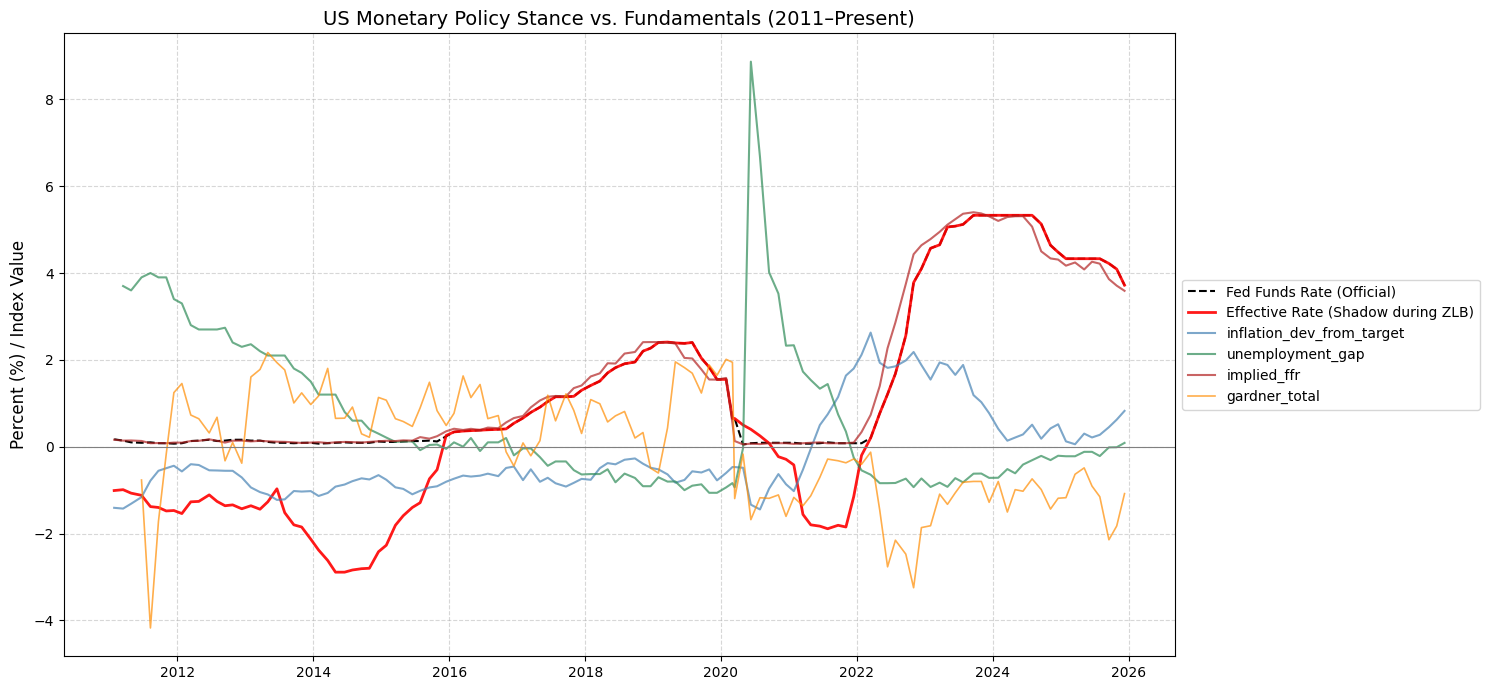

In [8]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4: VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════

COLORS = ['steelblue', 'seagreen', 'firebrick', 'darkorange',
          'purple', 'teal', 'saddlebrown', 'hotpink']

fig, ax = plt.subplots(figsize=(15, 7))

# ── Always plotted: policy rates ──────────────────────────────────────────────
ax.plot(df_final.index, df_final['fed_funds_rate'],
        label='Fed Funds Rate (Official)', color='black',
        linewidth=1.5, linestyle='--')
ax.plot(df_final.index, df_final['effective_rate'],
        label='Effective Rate (Shadow during ZLB)', color='red',
        linewidth=2, alpha=0.9)

# ── User-specified regressors ─────────────────────────────────────────────────
for i, col in enumerate(Regressors):
    if col in df_final.columns:
        ax.plot(df_final.index, df_final[col],
                label=col, color=COLORS[i % len(COLORS)],
                linewidth=1.5, alpha=0.7)
    else:
        print(f"  ⚠️  Regressor '{col}' not found in df_final — skipping")

# ── Sentiment indicators ──────────────────────────────────────────────────────
linestyles = ['-', '--', '-.', ':']
for i, name in enumerate(sentiment_dfs):
    color = COLORS[(len(Regressors) + i) % len(COLORS)]
    for j, col in enumerate(sentiment_cols[name]):
        if col in df_final.columns:
            ax.plot(df_final.index, df_final[col],
                    label=col, color=color,
                    linewidth=1.2, alpha=0.7,
                    linestyle=linestyles[j % len(linestyles)])
        else:
            print(f"  ⚠️  Sentiment column '{col}' not found in df_final — skipping")

ax.axhline(0, color='grey', linewidth=0.8)
ax.set_title('US Monetary Policy Stance vs. Fundamentals (2011–Present)', fontsize=14)
ax.set_ylabel('Percent (%) / Index Value', fontsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
ax.grid(True, which='major', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5: POLICY DECISION CLASSIFICATION
# ══════════════════════════════════════════════════════════════════════════════

df_model = df_final.copy()
df_model['rate_change'] = df_model['effective_rate'].diff()

def classify_decision(change):
    if change > 0.01:    return  1   # hike
    elif change < -0.01: return -1   # cut
    else:                return  0   # hold

df_model['MPD'] = df_model['rate_change'].apply(classify_decision)

print("FOMC Decision distribution:")
print(df_model['MPD'].value_counts().rename({1: 'Hike', 0: 'Hold', -1: 'Cut'}))

FOMC Decision distribution:
MPD
Hike    62
Cut     42
Hold    17
Name: count, dtype: int64


# **OLS (endog = shadow rate, exog = Regressors)**

In [10]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6: OLS REGRESSION  (Taylor Rule augmented with sentiment)
# ══════════════════════════════════════════════════════════════════════════════

df_ols = df_model.copy()

# Target: next-meeting rate
df_ols['target_rate'] = df_ols['effective_rate'].shift(-1)

# ── Build predictors dynamically ──────────────────────────────────────────────
base_predictors = ['effective_rate']

sentiment_predictors = [
    c for name in sentiment_dfs
    for c in sentiment_cols[name]
    if c in df_final.columns
]

PREDICTORS = base_predictors + sentiment_predictors + [
    r for r in Regressors if r not in base_predictors
]

print(f"  Predictors: {PREDICTORS}")

# ── Run OLS ───────────────────────────────────────────────────────────────────
df_clean   = df_ols[['target_rate'] + PREDICTORS].dropna()
y          = df_clean['target_rate']
X          = sm.add_constant(df_clean[PREDICTORS])
ols_result = sm.OLS(y, X).fit()
print(ols_result.summary())


  Predictors: ['effective_rate', 'gardner_total', 'inflation_dev_from_target', 'unemployment_gap', 'implied_ffr']
                            OLS Regression Results                            
Dep. Variable:            target_rate   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     2292.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          3.16e-110
Time:                        14:25:05   Log-Likelihood:               -0.88156
No. Observations:                 117   AIC:                             13.76
Df Residuals:                     111   BIC:                             30.34
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--

# **Ordinal Probit (endog = Shadow rate, exog = Regressors):**



In [11]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7: ORDINAL PROBIT  (Hike / Hold / Cut)
# ══════════════════════════════════════════════════════════════════════════════

base_predictors = ['effective_rate']

sentiment_predictors = [
    c for name in sentiment_dfs
    for c in sentiment_cols[name]
    if c in df_final.columns
]

ORDINAL_PREDICTORS = base_predictors + sentiment_predictors + [
    r for r in Regressors if r not in base_predictors
]

print(f"  Predictors: {ORDINAL_PREDICTORS}")

# ── Predict next meeting's decision ───────────────────────────────────────────
y_ord = df_model['MPD'].shift(-1).dropna()
X_ord = df_model[ORDINAL_PREDICTORS]

common_idx    = y_ord.index.intersection(X_ord.dropna().index)
y_ord         = y_ord.loc[common_idx]
X_ord         = X_ord.loc[common_idx]

ordinal_model  = OrderedModel(y_ord, X_ord, distr='probit')
ordinal_result = ordinal_model.fit(method='bfgs', disp=False)
print(ordinal_result.summary())


  Predictors: ['effective_rate', 'gardner_total', 'inflation_dev_from_target', 'unemployment_gap', 'implied_ffr']
                             OrderedModel Results                             
Dep. Variable:                    MPD   Log-Likelihood:                -95.966
Model:                   OrderedModel   AIC:                             205.9
Method:            Maximum Likelihood   BIC:                             225.3
Date:                Mon, 09 Mar 2026                                         
Time:                        14:25:05                                         
No. Observations:                 117                                         
Df Residuals:                     110                                         
Df Model:                           5                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

# **Ordinal Probit (endog = Real rate, exog = Regressors):**


In [12]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8: ORDINAL PROBIT  (Hike / Hold / Cut) using actual FFR
# ══════════════════════════════════════════════════════════════════════════════

df_model['rate_change_actual'] = df_model['fed_funds_rate'].diff()

def classify_decision(change):
    if change > 0.01:    return  1   # hike
    elif change < -0.01: return -1   # cut
    else:                return  0   # hold

df_model['MPD_actual'] = df_model['rate_change_actual'].apply(classify_decision)

print("FOMC Actual Decision distribution:")
print(df_model['MPD_actual'].value_counts().rename({1: 'Hike', 0: 'Hold', -1: 'Cut'}))

# ── Build predictors dynamically ──────────────────────────────────────────────
base_predictors = ['MPD_actual']

sentiment_predictors = [
    c for name in sentiment_dfs
    for c in sentiment_cols[name]
    if c in df_final.columns
]

ORDINAL_PREDICTORS = base_predictors + sentiment_predictors + [
    r for r in Regressors if r not in base_predictors
]

print(f"  Predictors: {ORDINAL_PREDICTORS}")

# ── Predict next meeting's decision ───────────────────────────────────────────
y_ord = df_model['MPD_actual'].shift(-1).dropna()
X_ord = df_model[ORDINAL_PREDICTORS]

common_idx    = y_ord.index.intersection(X_ord.dropna().index)
y_ord         = y_ord.loc[common_idx]
X_ord         = X_ord.loc[common_idx]

ordinal_model  = OrderedModel(y_ord, X_ord, distr='probit')
ordinal_result = ordinal_model.fit(method='bfgs', disp=False)
print(ordinal_result.summary())


FOMC Actual Decision distribution:
MPD_actual
Hike    51
Hold    43
Cut     27
Name: count, dtype: int64
  Predictors: ['MPD_actual', 'gardner_total', 'inflation_dev_from_target', 'unemployment_gap', 'implied_ffr']
                             OrderedModel Results                             
Dep. Variable:             MPD_actual   Log-Likelihood:                -109.00
Model:                   OrderedModel   AIC:                             232.0
Method:            Maximum Likelihood   BIC:                             251.3
Date:                Mon, 09 Mar 2026                                         
Time:                        14:25:05                                         
No. Observations:                 117                                         
Df Residuals:                     110                                         
Df Model:                           5                                         
                                coef    std err          z      P>|z|     

# **Walk Forward Cross Validation**

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9: WALK-FORWARD ECONOMIC VALIDATION
# Strategy: at each FOMC meeting, train an expanding-window ordered probit on
# all prior meetings, then take a position in fed funds futures for the next
# inter-meeting window.
#
# Signal  = P(Hike) - P(Cut)   ∈ [-1, +1]
#   > 0  → short the futures  (expect rate ↑ → futures price ↓)
#   < 0  → long  the futures  (expect rate ↓ → futures price ↑)
#
# Return proxy: we don't have tick-level futures data, so we approximate the
# one-month futures P&L as minus the actual rate change (in basis points).
# Futures price = 100 - FFR, so Δprice ≈ -Δrate.
# A long position earns  +|Δrate| when rates fall, -|Δrate| when they rise.
# The dollar P&L of a $1 position is therefore: signal × (-Δrate_next).
#
# For a statistical alternative, skip to the bottom of this cell where
# in-sample p-values from the full probit are printed directly.
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.miscmodels.ordinal_model import OrderedModel
import warnings

# ── Config ────────────────────────────────────────────────────────────────────
MIN_TRAIN_OBS = 20        # minimum meetings before we start predicting
SIGNAL_THRESHOLD = 0.05   # minimum |signal| to enter a trade (avoids noise)
MEETINGS_PER_YEAR = 8     # approximate FOMC meetings per year

# ── Build the modelling frame (same predictors as Cell 8) ────────────────────
base_predictors = ['MPD_actual']
sentiment_predictors = [
    c for name in sentiment_dfs
    for c in sentiment_cols[name]
    if c in df_final.columns
]
WF_PREDICTORS = base_predictors + sentiment_predictors + [
    r for r in Regressors if r not in base_predictors
]

df_wf = df_model[WF_PREDICTORS + ['MPD_actual', 'fed_funds_rate']].copy()
df_wf['next_MPD']  = df_wf['MPD_actual'].shift(-1)
df_wf['delta_rate'] = df_wf['fed_funds_rate'].diff().shift(-1)  # rate change at NEXT meeting
df_wf = df_wf.dropna(subset=['next_MPD', 'delta_rate'] + WF_PREDICTORS)

print(f"Walk-forward frame: {len(df_wf)} meetings, predictors: {WF_PREDICTORS}\n")

# ── Expanding-window walk-forward loop ────────────────────────────────────────
results = []

meeting_dates = df_wf.index.tolist()

for i in range(MIN_TRAIN_OBS, len(meeting_dates)):
    train_idx = meeting_dates[:i]
    pred_date  = meeting_dates[i]

    df_train = df_wf.loc[train_idx]
    row_pred  = df_wf.loc[[pred_date]]

    X_train = df_train[WF_PREDICTORS]
    y_train = df_train['next_MPD']

    # Skip if training labels are degenerate (only one class)
    if y_train.nunique() < 2:
        continue

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = OrderedModel(y_train, X_train, distr='probit')
            res = m.fit(method='bfgs', disp=False, maxiter=200)

        probs = res.predict(row_pred[WF_PREDICTORS])
        # OrderedModel returns columns in ascending label order: Cut(-1), Hold(0), Hike(1)
        sorted_labels = sorted(y_train.unique())
        prob_df = pd.DataFrame(probs, columns=sorted_labels)

        p_hike = prob_df.get( 1, pd.Series([0.0])).iloc[0]
        p_cut  = prob_df.get(-1, pd.Series([0.0])).iloc[0]

        signal      = float(p_hike - p_cut)
        delta_rate  = float(df_wf.loc[pred_date, 'delta_rate'])
        # futures P&L: long = gains when rates fall; short = gains when rates rise
        futures_ret = signal * (-delta_rate)   # in basis-points-equivalent

        results.append({
            'date':       pred_date,
            'signal':     signal,
            'p_hike':     p_hike,
            'p_cut':      p_cut,
            'delta_rate': delta_rate,
            'futures_ret': futures_ret,
            'traded':     abs(signal) >= SIGNAL_THRESHOLD,
        })

    except Exception as e:
        continue

df_results = pd.DataFrame(results).set_index('date')
print(f"Predictions generated: {len(df_results)}  |  "
      f"Trades taken: {df_results['traded'].sum()}\n")

# ── Performance (all signals) ─────────────────────────────────────────────────
all_rets   = df_results['futures_ret']
trade_rets = df_results.loc[df_results['traded'], 'futures_ret']

def sharpe(series, periods_per_year=MEETINGS_PER_YEAR):
    if series.std() == 0 or len(series) < 2:
        return np.nan
    return (series.mean() / series.std()) * np.sqrt(periods_per_year)

print("═" * 55)
print("  WALK-FORWARD PERFORMANCE SUMMARY")
print("═" * 55)
print(f"  All-signal Sharpe  : {sharpe(all_rets):.3f}")
print(f"  Filtered Sharpe    : {sharpe(trade_rets):.3f}  "
      f"(|signal| ≥ {SIGNAL_THRESHOLD})")
print(f"  Hit rate (all)     : "
      f"{(np.sign(df_results['signal']) == -np.sign(df_results['delta_rate'])).mean():.1%}")
print(f"  Hit rate (filtered): "
      f"{(np.sign(trade_rets) > 0).mean():.1%}")
print(f"  Mean signal        : {all_rets.mean():.4f} bps")
print(f"  Cumulative P&L     : {all_rets.sum():.2f} bps")
print("═" * 55)

# ── Plot cumulative P&L ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_results.index, df_results['signal'],
             color='steelblue', linewidth=1.2, label='Signal P(Hike)−P(Cut)')
axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].axhline( SIGNAL_THRESHOLD, color='grey', linewidth=0.6, linestyle=':')
axes[0].axhline(-SIGNAL_THRESHOLD, color='grey', linewidth=0.6, linestyle=':')
axes[0].set_ylabel('Signal')
axes[0].set_title('Walk-Forward Fed Funds Futures Strategy (Expanding Window Probit)')
axes[0].legend()

axes[1].plot(df_results.index, all_rets.cumsum(),
             color='firebrick', linewidth=1.5, label='Cumulative P&L (bps)')
axes[1].axhline(0, color='grey', linewidth=0.8)
axes[1].set_ylabel('Cumulative bps')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Statistical summary (p-values) — no trading required ─────────────────────
print("\n\nIN-SAMPLE STATISTICAL VALIDATION (full-sample probit p-values)")
print("This replicates Gardner Table 3 / Table 4 logic.")
print("─" * 55)
y_full = df_wf['next_MPD']
X_full = df_wf[WF_PREDICTORS]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    m_full  = OrderedModel(y_full, X_full, distr='probit')
    res_full = m_full.fit(method='bfgs', disp=False)
print(res_full.summary())


ValueError: Cannot set a DataFrame with multiple columns to the single column next_MPD